Строим графики времени выполнения...


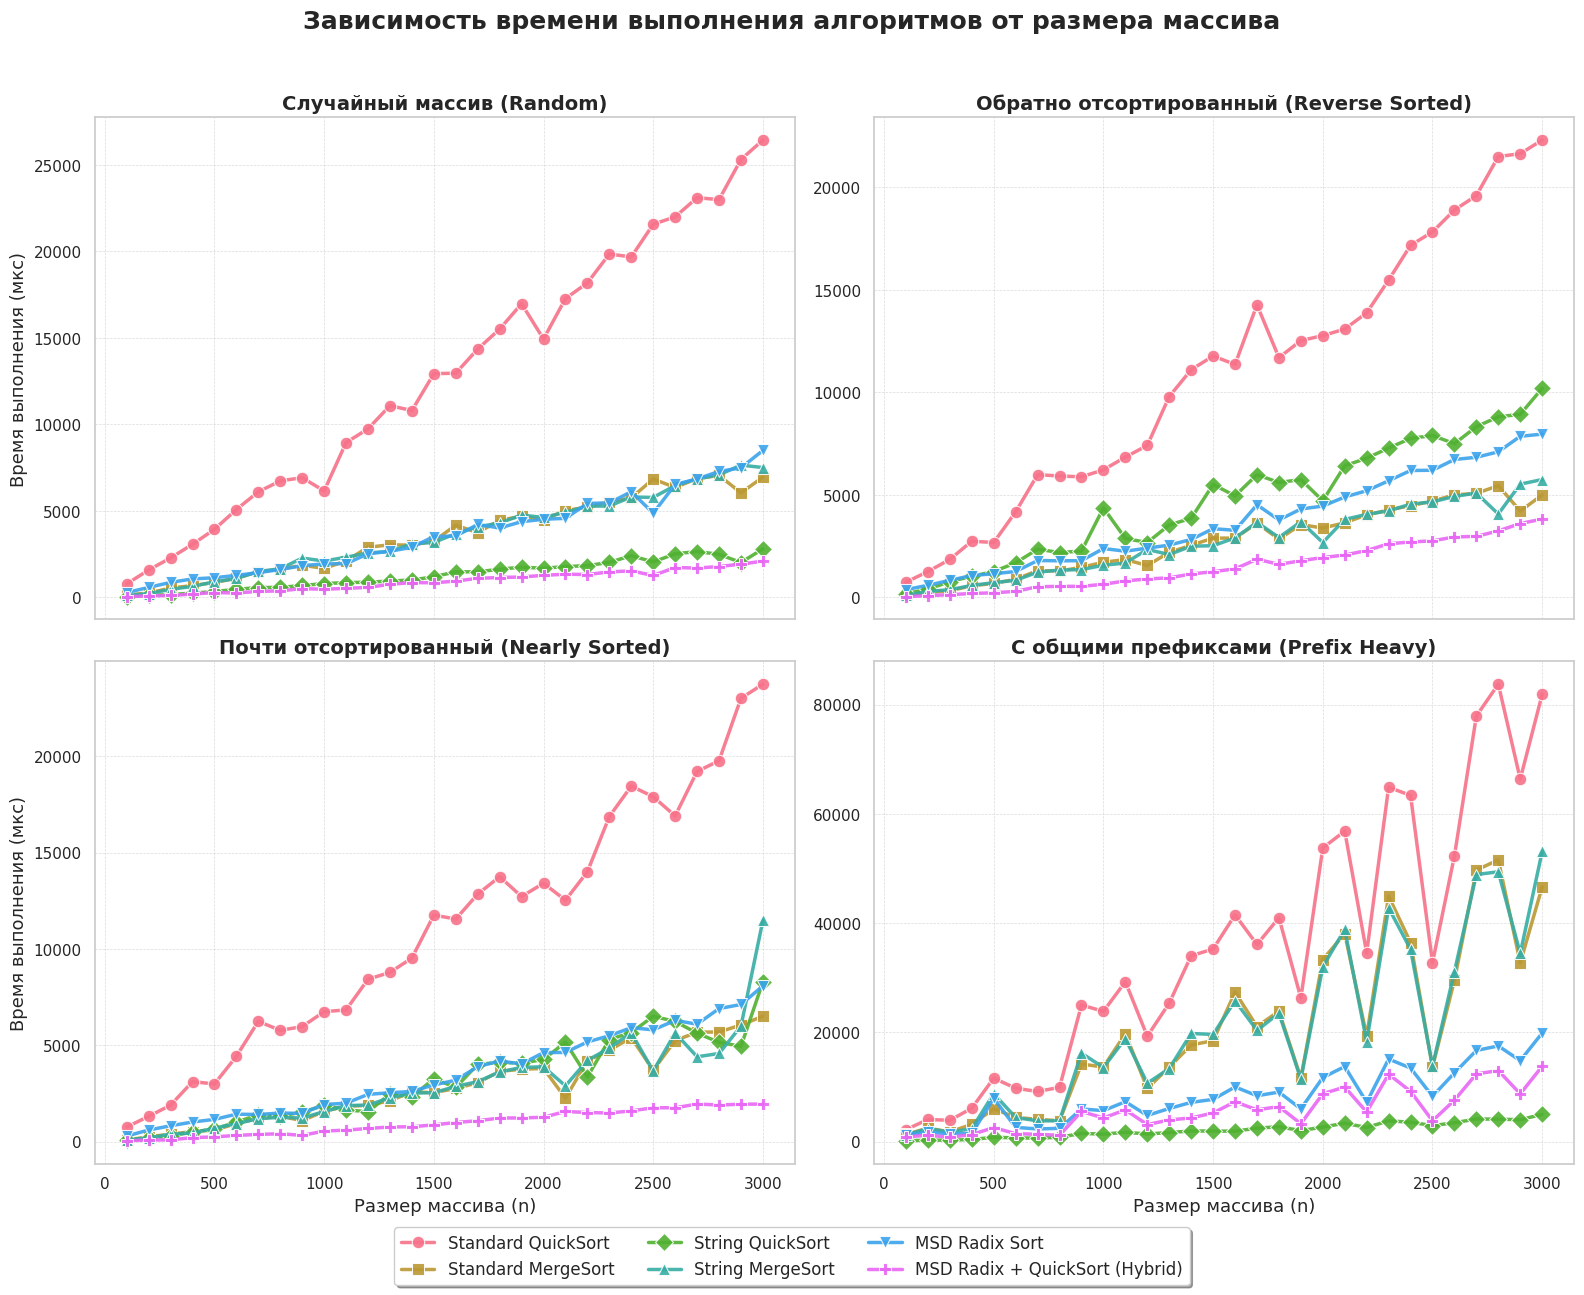

Строим графики количества сравнений...


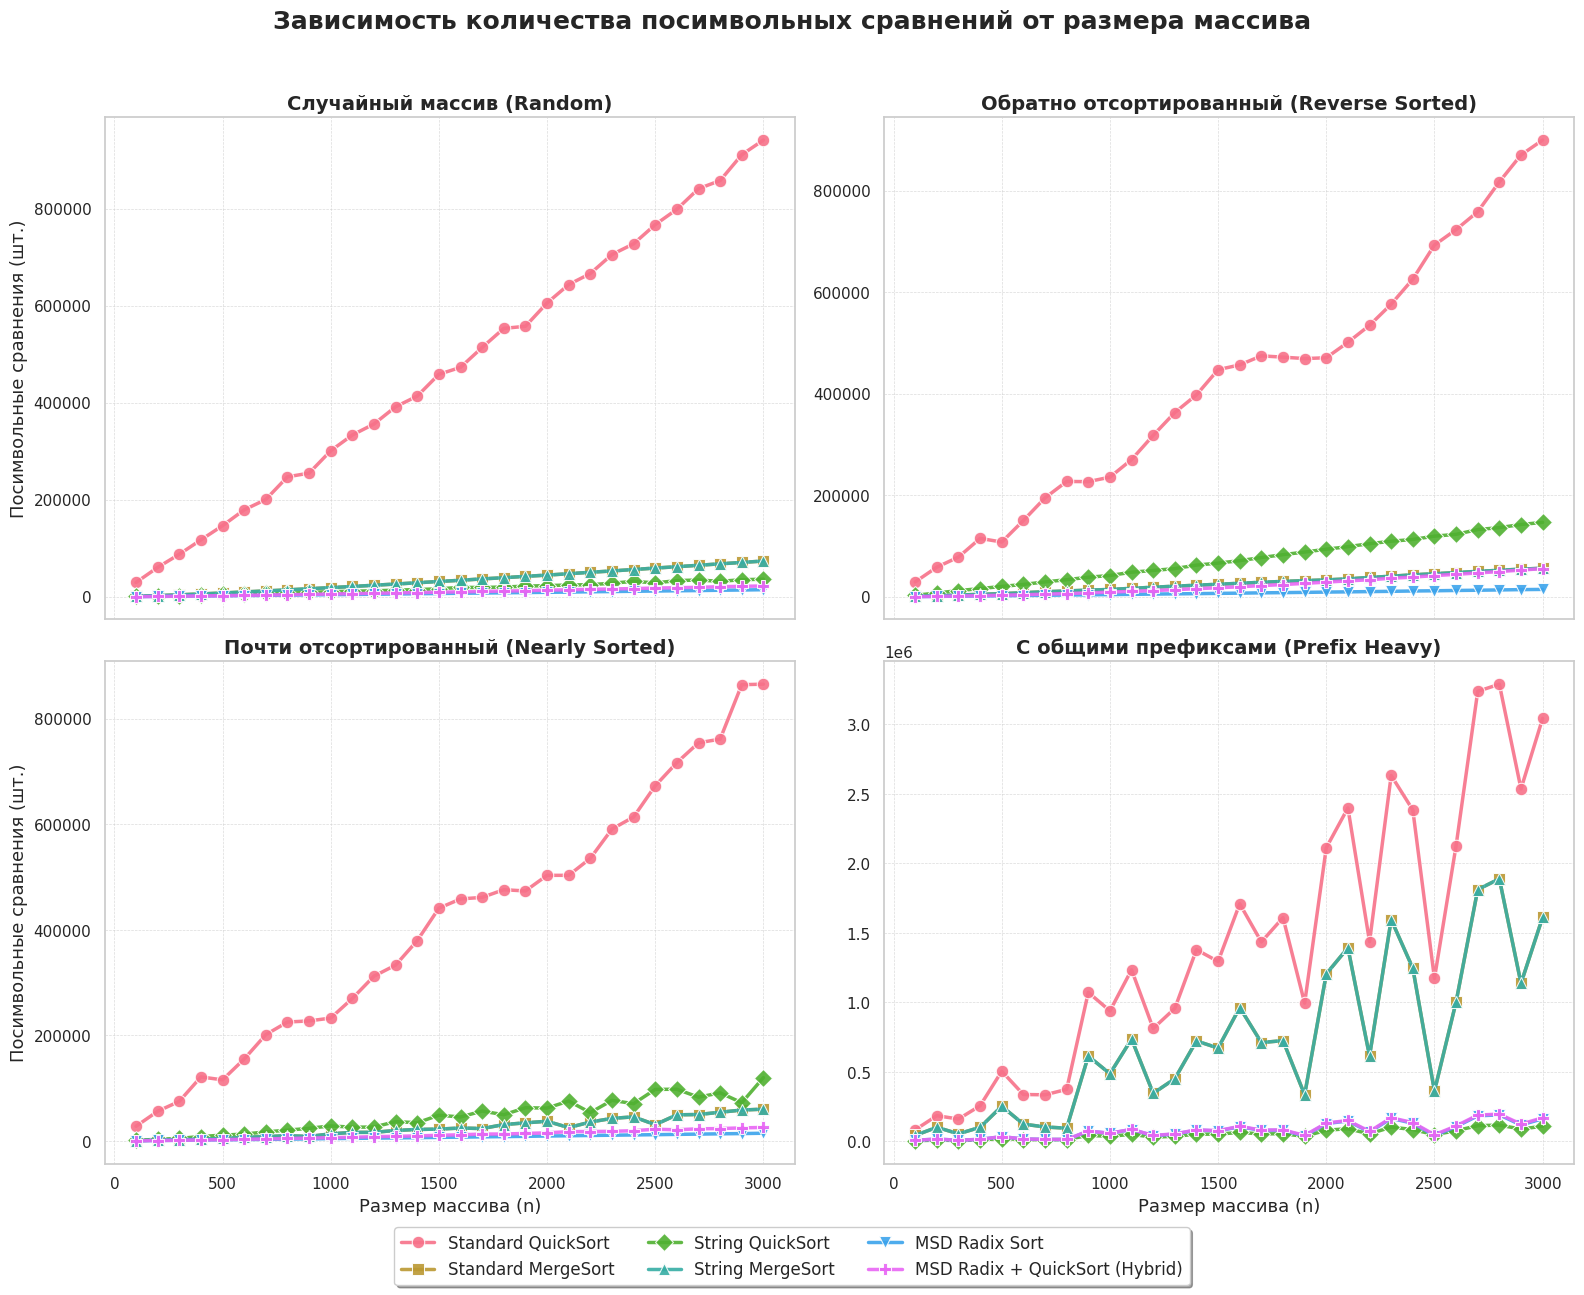

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13,
    'figure.titlesize': 18,
    'figure.autolayout': True
})

# Загрузка данных
df = pd.read_csv('results.csv')

# Красивые названия алгоритмов
algo_names = {
    'quick_sort': 'Standard QuickSort',
    'merge_sort': 'Standard MergeSort',
    'string_quick_sort': 'String QuickSort',
    'string_merge_sort': 'String MergeSort',
    'msd_radix_sort': 'MSD Radix Sort',
    'msd_radix_quick_sort': 'MSD Radix + QuickSort (Hybrid)'
}
df['algorithm'] = df['algorithm'].map(algo_names)

# Красивые названия датасетов
titles = {
    'random': 'Случайный массив (Random)',
    'reverse_sorted': 'Обратно отсортированный (Reverse Sorted)',
    'nearly_sorted': 'Почти отсортированный (Nearly Sorted)',
    'prefix_heavy': 'С общими префиксами (Prefix Heavy)'
}

# Палитра и маркеры для алгоритмов, чтобы они легко различались
palette = sns.color_palette("husl", 6)
markers = ['o', 's', 'D', '^', 'v', 'P']

def plot_beautiful_grid(metric, ylabel, filename, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
    axes = axes.flatten()

    for i, dataset in enumerate(titles.keys()):
        ax = axes[i]
        subset = df[df['dataset'] == dataset]

        sns.lineplot(
            data=subset,
            x='size',
            y=metric,
            hue='algorithm',
            style='algorithm',
            palette=palette,
            markers=markers,
            dashes=False,
            ax=ax,
            linewidth=2.5,
            markersize=9,
            alpha=0.9
        )

        ax.set_title(titles[dataset], fontweight='bold')
        ax.set_xlabel('Размер массива (n)' if i >= 2 else '')
        ax.set_ylabel(ylabel if i % 2 == 0 else '')

        # Включаем минорную сетку для лучшей читаемости
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.get_legend().remove() # Удаляем локальные легенды

    # Создаем общую легенду внизу графика
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=True, shadow=True)

    fig.suptitle(suptitle, fontweight='bold', y=1.02)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

print("Строим графики времени выполнения...")
plot_beautiful_grid(
    'average_time_microseconds',
    'Время выполнения (мкс)',
    'time_plot.png',
    'Зависимость времени выполнения алгоритмов от размера массива'
)

print("Строим графики количества сравнений...")
plot_beautiful_grid(
    'average_character_comparisons',
    'Посимвольные сравнения (шт.)',
    'comparisons_plot.png',
    'Зависимость количества посимвольных сравнений от размера массива'
)